# Exploratory Data Analysis (EDA)
## Wisconsin Diagnostic Breast Cancer 

_Last Updated: 2026-03-05_

---

# Motivating Problem
##### Can we develop a machine learning model to assist radiologists in distinguishing malignant from benign breast masses using cell morphology features, in order to reduce unnecessary biopsies while maintaining high cancer detection rates?

### Approach
Our dataset exploration was driven by model considerations and targeted the following questions:
1. What is the prediction problem?
2. What does the data look like?
3. What could break a model?
4. What structure exists in the features?
5. What modelling decisions does this imply?

<!-- - Class distribution: is imbalance a concern? SLIGHTLY
- Missing heatmap: is preprocessing complex? NOT AT ALL
- histograms: do features separate classes? SOME, YES AND VERY WELL
- boxplots: are outliers influential? MAYBE BUT THEY ARE EXPECTED SO NOT OUTLIERS
- correlation heatmap: is multicollinearity present? VERY MUCH SO
- pairplots: is linear modeling reasonable? YES
- scale comparison: do we need normalization? YES
- feature importance: is signal concentrated? YES  -->

### Notebook Outline
- [Dataset Overview](#1-dataset-overview)
- [Target Variable Analysis](#2-target-variable-analysis)
- [Univariate Feature Analysis](#3-univaritate-feature-analysis)
    <!-- - [Boxplots & Outlier Detection](#31-boxplots--outlier-detection)
    - [Feature Distribution](#32-feature-distribution) -->
- [Feature Correlation Analysis](#4-feature-correlation-analysis)
- [Preliminary Feature Importance](#5-preliminary-feature-importance)
- [Potential Risks & Unknowns](#6-potential-risks--unknowns)
- [Proposed Modeling Plan](#7-proposed-modeling-plan)

_Note: Jupyter Notebook's within-document hyperlinks do not render on GitHub, but will work if running the .ipynb in an IDE such as VS Code_

## 1. Dataset Overview
The [Wisconsin Diagnostic Breast Cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) (WDBC) contains 569 samples (instances) of 30 real-valued input features derived from digitized images of fine needle aspirates (FNAs) of breast masses to predict tumor malignancy. Features describe 10 core characteristics of cell nuclei present in the image, and there are three calculations per feature — mean, standard error, and worst (mean of three largest values).

**Target Variable**: 
- binary classification 
- **classes**: "Malignant" (1) or "Benign" (0)

**Core Feature Definitions**:
- **radius**:           mean of distances from the center to points on the perimeter
- **texture**:          standard deviation of gray-scale values
- **perimeter**:        total length of the boundary
- **area**:             surface area of the nucleus
- **smoothness**:       local variation in radius lengths
- **compactness**:      $\mathrm{(perimeter}^2/\mathrm{area)} - 1.0$
- **concavity**:        severity of concave portions of the contour
- **concave points**:   number of concave portions of the contour
- **symmetry**:         surface symmetry
- **fractal dimension**: "coastline approximation" - 1 

**Key Measures**: mean, standard error, worst

### 1.0 Import Modules
_The src/ folder contains python (.py) scripts needed for running the .ipynb files contained in the notebooks/ (this) folder. The functions in each script help with a certain aspect of the project. At the top of each .ipynb in the notebooks/ folder you will find a code block that sets up access to the src/ folder and its functions. If you remove this code block you will not be able to properly run the notebook._

In [1]:
import sys
from pathlib import Path

# Get repo root (one level above notebooks/)
repo_root = Path().resolve().parent
src_path = repo_root / "src"

# Add src folder to Python path
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# import modules
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# import custom modules
from preprocessing import load_raw_data
from check import data_quality_report
# from visualization import visualize_missing, plot_class_distribution
import visualization as vis

# settings
sns.set_style(style="white")
print("> Loaded required libraries")

> Loaded required libraries


In [2]:
# hard-coded variables or flags
data_path = "../data/raw/wdbc.data"
cols = {"malignant": "darkblue", "benign": "skyblue"} # target
measures = ["mean", "error", "worst"]
measures_cols = {"mean": "#3498DB", "error": "#F39C12", "worst": "#E74C3C"} # measures

### 1.1 Load and Inspect the Data
To ensure complete reproducibility, we have landed the original `wdbc.data` dataset in the `data/raw/` repository folder. The original dataset can also be found on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/) website.

The raw dataset is loaded and cleaned using a helper function. Cleaning steps include standardizing column names and encoding the target variable (malignant = 1, benign = 0). Next, we confirm these data look as expected.

In [3]:
# load dataset
df = load_raw_data(data_path)

# collect column names
feature_names = df.select_dtypes(include = "number").columns.tolist()
target_names = df["diagnosis"].unique().tolist()

# get overview
print(f"Shape of dataset: {df.shape}")
print(f"Target classes ({len(target_names)}): {target_names}")
print(f"Features ({len(feature_names)}): {feature_names}\n")

# check that there are 10 features per measurement
for m in measures:
    count = sum(m in col for col in df.columns)
    print(f"{count} {m} features")

df.head() # snapshot

Shape of dataset: (569, 31)
Target classes (2): ['malignant', 'benign']
Features (30): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

10 mean features
10 error features
10 worst features


,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,malignant,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,malignant,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,malignant,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,malignant,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,malignant,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# print summary of df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   diagnosis                569 non-null    category
 1   mean radius              569 non-null    float64 
 2   mean texture             569 non-null    float64 
 3   mean perimeter           569 non-null    float64 
 4   mean area                569 non-null    float64 
 5   mean smoothness          569 non-null    float64 
 6   mean compactness         569 non-null    float64 
 7   mean concavity           569 non-null    float64 
 8   mean concave points      569 non-null    float64 
 9   mean symmetry            569 non-null    float64 
 10  mean fractal dimension   569 non-null    float64 
 11  radius error             569 non-null    float64 
 12  texture error            569 non-null    float64 
 13  perimeter error          569 non-null    float64 
 14  area error           

#### Observations:
- df is the correct shape (569, 31), with 30 feature columns consisting of real numbers and 1 target column (`diagnosis`) consisting of 2 categorical variables - malignant and benign 
- there are 10 features per measurement, and feature names are labelled according to whether the measurement represents the `mean`, `error`, or `worst` 
- all features are numeric
- lack of any missing values reduces preprocessing complexity

### 1.2 Data Quality & Cleaning
Before conducting any analyses we need to address data quality issues that could impact model quality and/or stability: missing values, duplicates, and zero-variance features.

A visual representation is a quick and helpful way to determine the distribution of missing values across the dataset. If the plot shows structure around a certain feature (column) or set of rows we might suspect missing values not at random. 

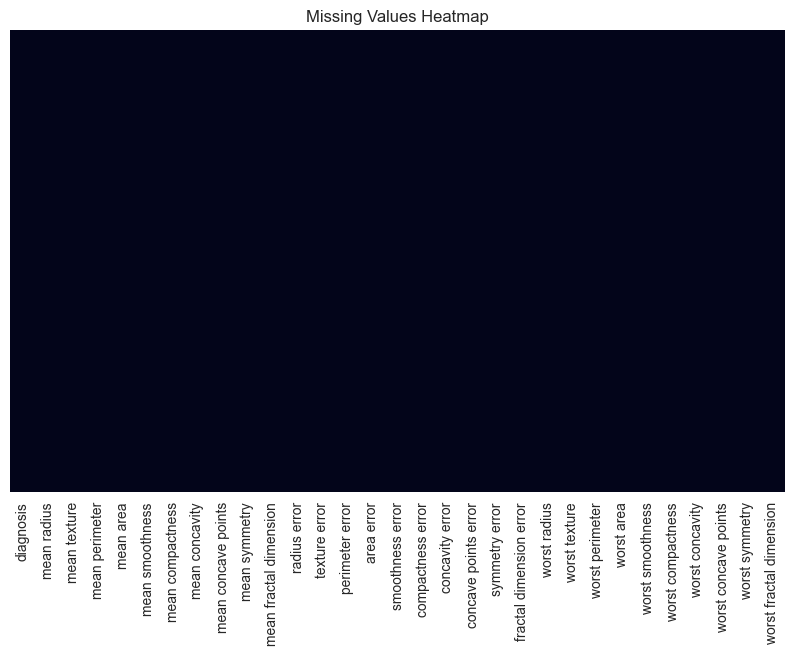

Missing values: 0
Duplicate rows: 0
Zero-variance features: None


['malignant', 'benign']
Categories (2, str): ['malignant', 'benign']

In [5]:
# Visualize missing values
vis.visualize_missing(df)

# check for na, exact row duplicates, constant variance
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
zero_var = [col for col in feature_names if df[col].nunique() == 1]
print(f"Zero-variance features: {zero_var if zero_var else 'None'}")

# ensure class label consistency
df["diagnosis"].unique()

#### Observations:
- No missing values reduces preprocessing complexity - no imputation required.
- No exact row duplicates - each observation only contributes once.
- No zero-variance features found - all features have predictive potential.

### 1.3 Summary Statistics
Although we have not yet considered the influence of outliers, it is still helpful to compute summary statistics on the cleaned data to get a numerical snapshot of each variable:

In [6]:
# Summary statistics
df.describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


## 2. Target Variable Analysis
We examine the distribution of the target classes by obtaining class counts and proportions to determine if reporting model accuracy as our primary metric would be misleading due to class imbalance.

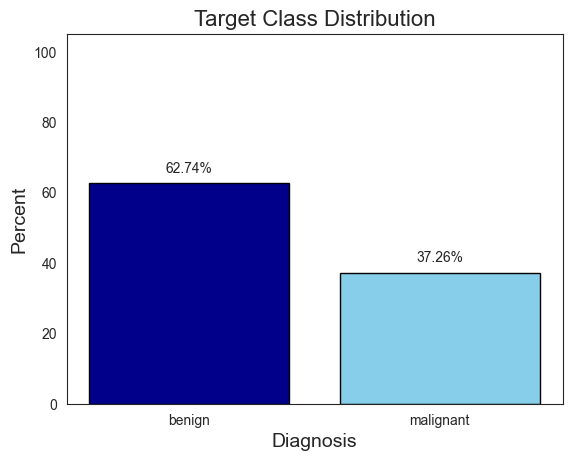

           Count  Percentage (%)
diagnosis                       
benign       357           62.74
malignant    212           37.26


In [ ]:
# calculate diagnosis class counts and percentages
counts, pcts = vis.plot_class_distribution(df, column="diagnosis", colors=cols)
print(pd.DataFrame({"Count": counts, "Percentage (%)": pcts.round(2)}))

### Observations:
- the classes are moderately imbalanced (~37% malignant, ~63% benign) 
- **use stratefied splitting for modeling and evaluate with sensitivity/specificity rather than accuracy alone**
- a naive majority classifier would achieve ~63%, so any model must exceed this

## 3. Univaritate Feature Analysis
### 3.1 Feature Correlation Analysis


# 3. Univaritate Feature Analysis
Histograms and boxplots of our numeric predictors reveals which features best separate the two classes, and allows us to identify skewed distributions and potential outliers.  

Exploratory distribution plots were generated for all 30 features to inspect class separation and skewness; representative examples are shown below.

## 3.1 Feature Distributions
Overlapping histograms reveal which features best separate the two classes. 

In [ ]:
## Feature Distributions

# create one figure per measure
for m in measures:
    feats = [col for col in df.columns if col.__contains__(m)]

    fig, axes = plt.subplots(5, 2, figsize=(8, 16))
    axes = axes.flatten()

    # create one histogram per feature
    for i, ft in enumerate (feats):
        for dx, col in cols.items(): 
            
            # split features by class
            subset = df[df["diagnosis"] == dx][ft]

            axes[i].hist(
                subset,
                bins = 25,
                alpha = 0.8,
                color = col,
                label = dx,
                edgecolor = "black",
                linewidth = 0.4
            )
        
        # add sub-figure titles, axes, legend
        axes[i].set_title(ft.title(), fontsize=10)
        axes[i].set_xlabel('Value', fontsize=10)
        axes[i].set_ylabel('Count', fontsize=10)
        axes[i].legend(fontsize=10)

    # add figure title
    plt.suptitle(f"Feature Distributions by Diagnosis ({m.title()})", fontsize=16)
    plt.tight_layout()
    plt.show()

### Observations:
Look for: skewness, separation between classes, outliers
Comment on: which features show clear separation? heavy overlap? extreme values?

**Mean**:

**Error**:

**Worst**:

## 3.2 Boxplots & Outlier Detection
Next, we will check for potential outliers in the dataset using boxplots, which highlight the median (red line), spread (IQR), and potential outliers (> IQR * 1.5) for each feature across classes. 
<!-- could potentially flag outliers as a column -->

In [ ]:
## Boxplots & Outlier Detection

# create one figure per measure
for m in measures:
    feats = [col for col in df.columns if col.__contains__(m)]

    fig, axes = plt.subplots(5, 2, figsize = (8, 15))
    axes = axes.flatten()

    for i, ft in enumerate(feats):

        # split the data by diagnosis
        ben = df[df["diagnosis"] == "benign"][ft]
        mal = df[df["diagnosis"] == "malignant"][ft]

        # draw the boxplot
        bp = axes[i].boxplot(
            [ben, mal],
            tick_labels = ["Benign", "Malignant"],
            patch_artist = True,
            notch = False
        )
    
        # set boxes
        bp["boxes"][0].set_facecolor(cols["benign"])
        bp["boxes"][0].set_alpha(0.7)
        bp["boxes"][1].set_facecolor(cols["malignant"])
        bp["boxes"][1].set_alpha(0.7)

        # add title/label
        axes[i].set_title(ft.title(), fontsize=12)
        axes[i].set_ylabel("Value", fontsize=10)

        # turn off gridlines
        axes[i].set_axisbelow(False)
        axes[i].grid(False)

    plt.suptitle(f"Boxplots by Diagnosis ({m.title()})", fontsize=16)
    plt.tight_layout()
    plt.show()


### Observations:
Look for: skewness, separation between classes, outliers
Comment on: which features show clear separation? heavy overlap? extreme values?

**Mean**:
- discriminative: 

**Error**:
- discriminative: 

**Worst**:
- discriminative: radius, perimeter, area, concave points

# 4. Feature Correlation Analysis

High correlations between features can lead to multicollinearity, which will make certain models unstable and potentially misleading.

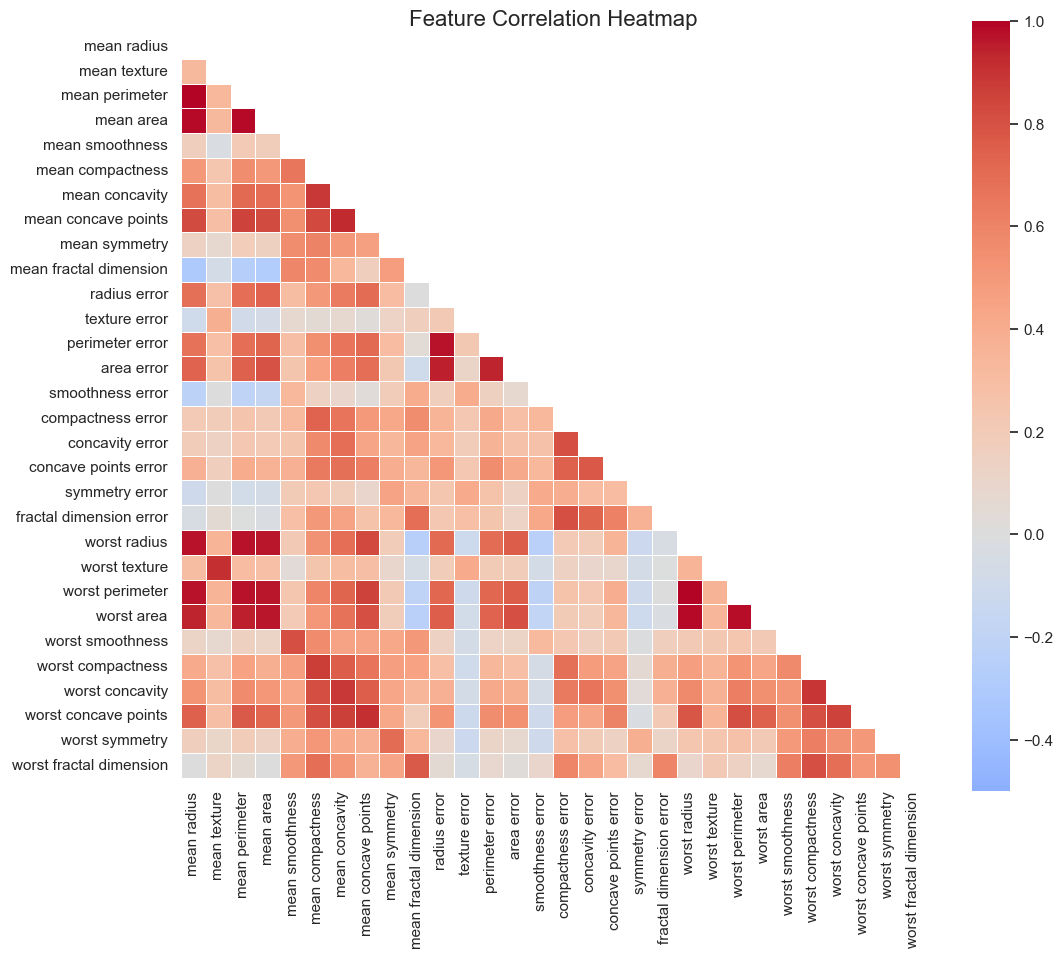

mean radius      mean perimeter    0.997855
worst perimeter  worst radius      0.993708
mean radius      mean area         0.987357
mean perimeter   mean area         0.986507
worst area       worst radius      0.984015
dtype: float64


In [166]:
## --- FEATURE CORRELATION HEATMAP --- ##

# Plot all 30
plt.figure(figsize = (12, 10))

# calculate correlations
corr = df.drop(columns = "diagnosis").corr()

# do not plot upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# plot correlation matrix
sns.heatmap(
    corr,
    mask = mask,
    cmap = "coolwarm",
    center = 0,
    square = True,
    linewidths = 0.5,
    vmin = -0.5,
    vmax = 1
)

# add title
plt.title("Feature Correlation Heatmap", fontsize = 16)
plt.show()

# get highest correlations
high_corr = corr[(abs(corr) > 0.9) & (abs(corr) < 1.0)]
print(high_corr.stack().sort_values(ascending=False).iloc[::2].head(5))

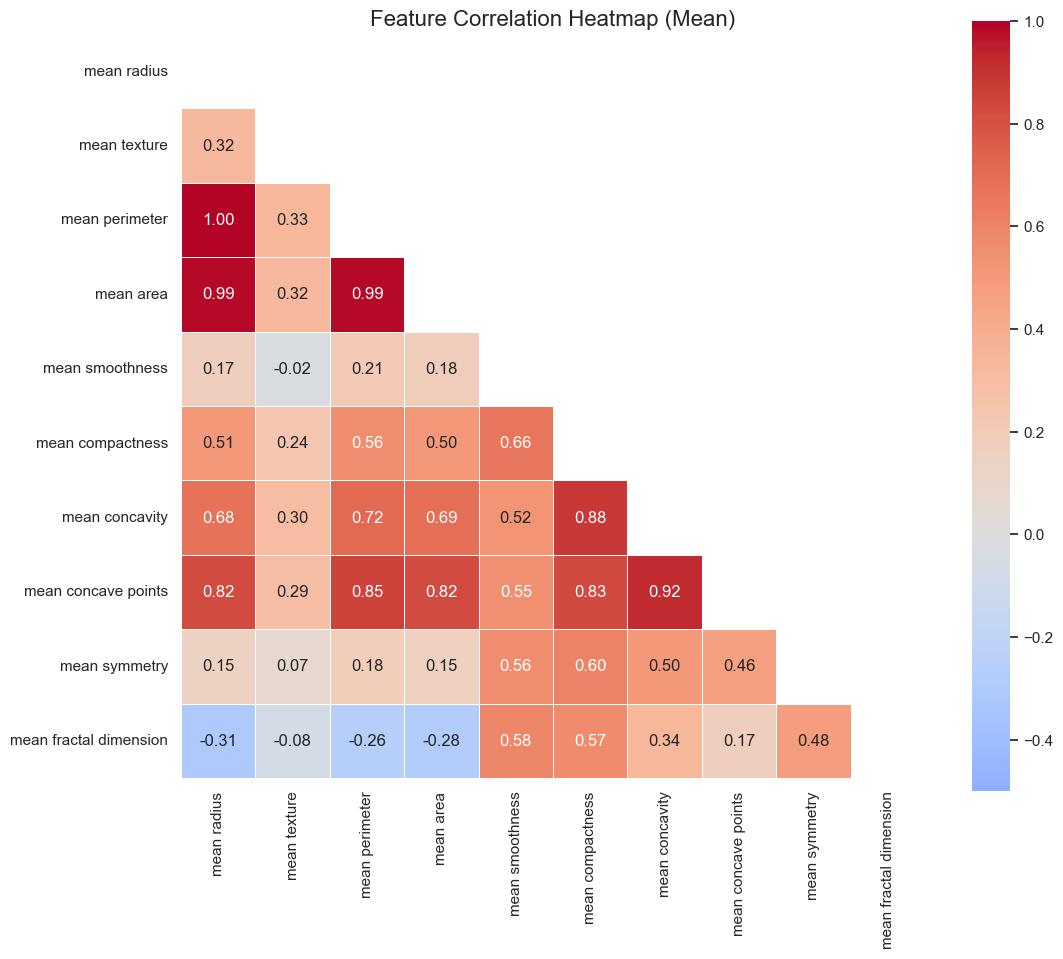

mean radius     mean perimeter    0.997855
                mean area         0.987357
mean perimeter  mean area         0.986507
dtype: float64


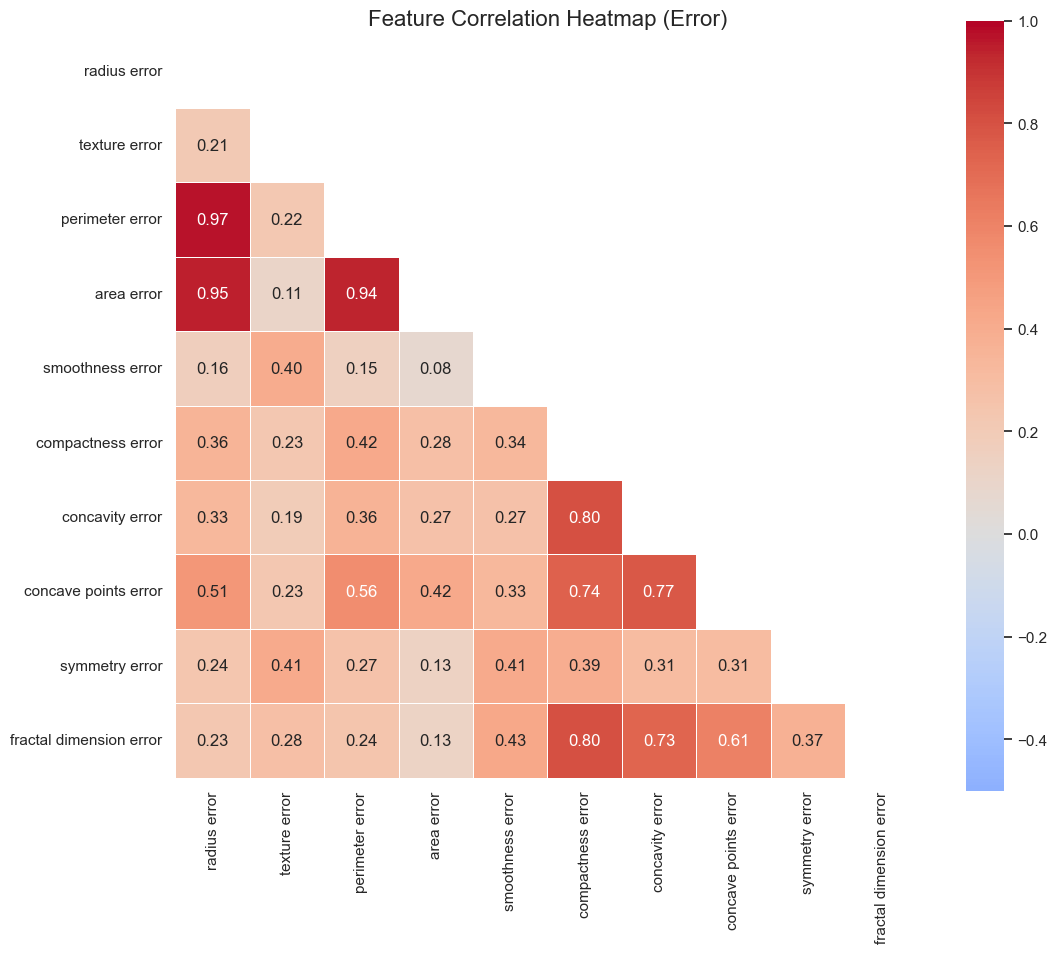

radius error     perimeter error    0.972794
                 area error         0.951830
perimeter error  area error         0.937655
dtype: float64


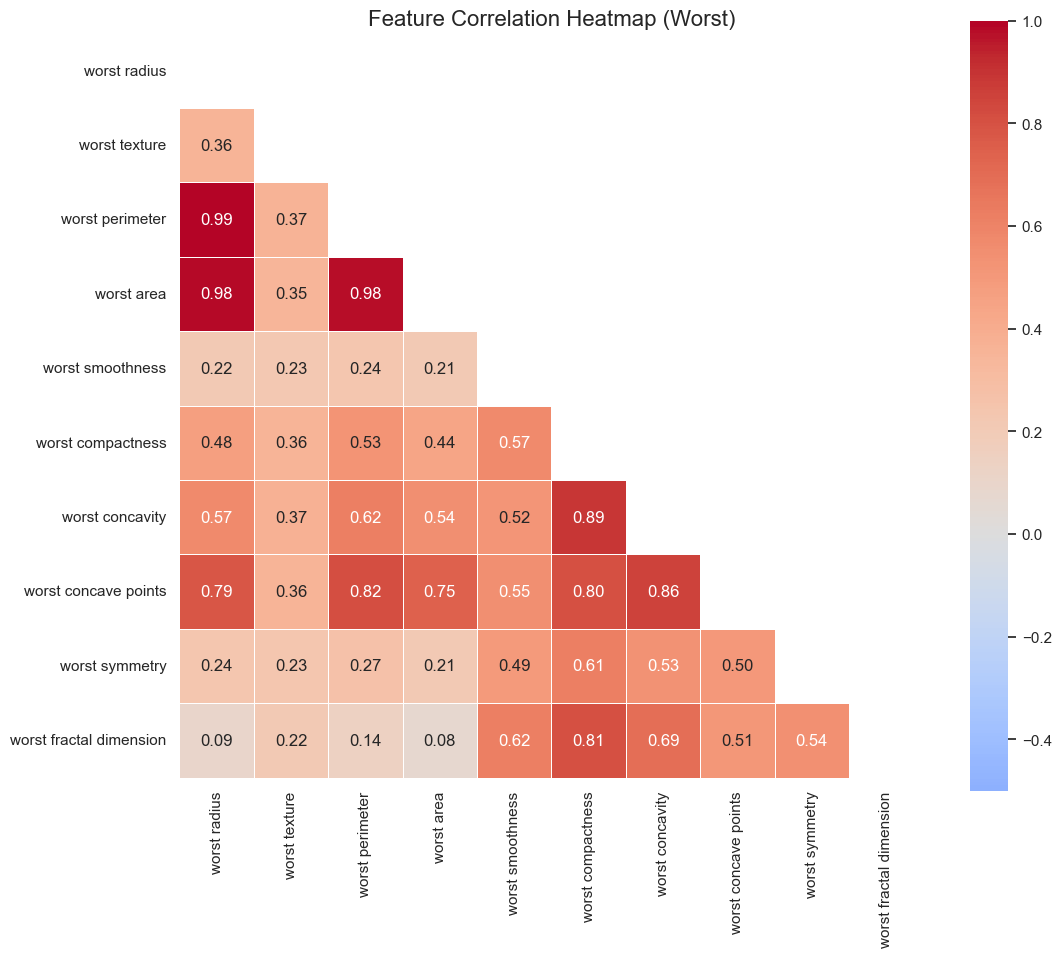

worst radius     worst perimeter    0.993708
                 worst area         0.984015
worst perimeter  worst area         0.977578
dtype: float64


In [165]:
## --- FEATURE CORRELATION HEATMAP --- ##

# Create one figure per measure
for m in measures:
    feats = [col for col in df.columns if col.__contains__(m)]

    plt.figure(figsize = (12, 10))

    # calculate correlations
    corr = df[feats].corr()

    # do not plot upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # plot correlation matrix
    sns.heatmap(
        corr,
        mask = mask,
        cmap = "coolwarm",
        center = 0,
        square = True,
        linewidths = 0.5,
        annot = True,
        fmt = ".2f",
        vmin = -0.5, 
        vmax = 1
    )

    # add title
    plt.title(f"Feature Correlation Heatmap ({m.title()})", fontsize = 16)
    plt.show()

    # get highest correlations
    high_corr = corr[(abs(corr) > 0.9) & (abs(corr) < 1.0)]
    print(high_corr.stack().sort_values(ascending=False).iloc[::2].head(3))

### Observations:
- Identify clusters (e.g., radius, perimeter, area)
- explain: multicollinearity implications, impact on logistic regression coefficients
    + "High correlation among radius, perimeter, and area may destabilize linear coefficients without regularization."

- radius, perimeter, and area are highly correlated - expected since they measure the same physical property
- a tree-based model can handle multicollinearity, but will affect logistic regression - use StandardScaler to handle scale differences

# 5. Pairwise Class Separation

## 5.1 Key Feature Relationships
Visualize how pairs of features separate the classes, along with a plot of the distributions.

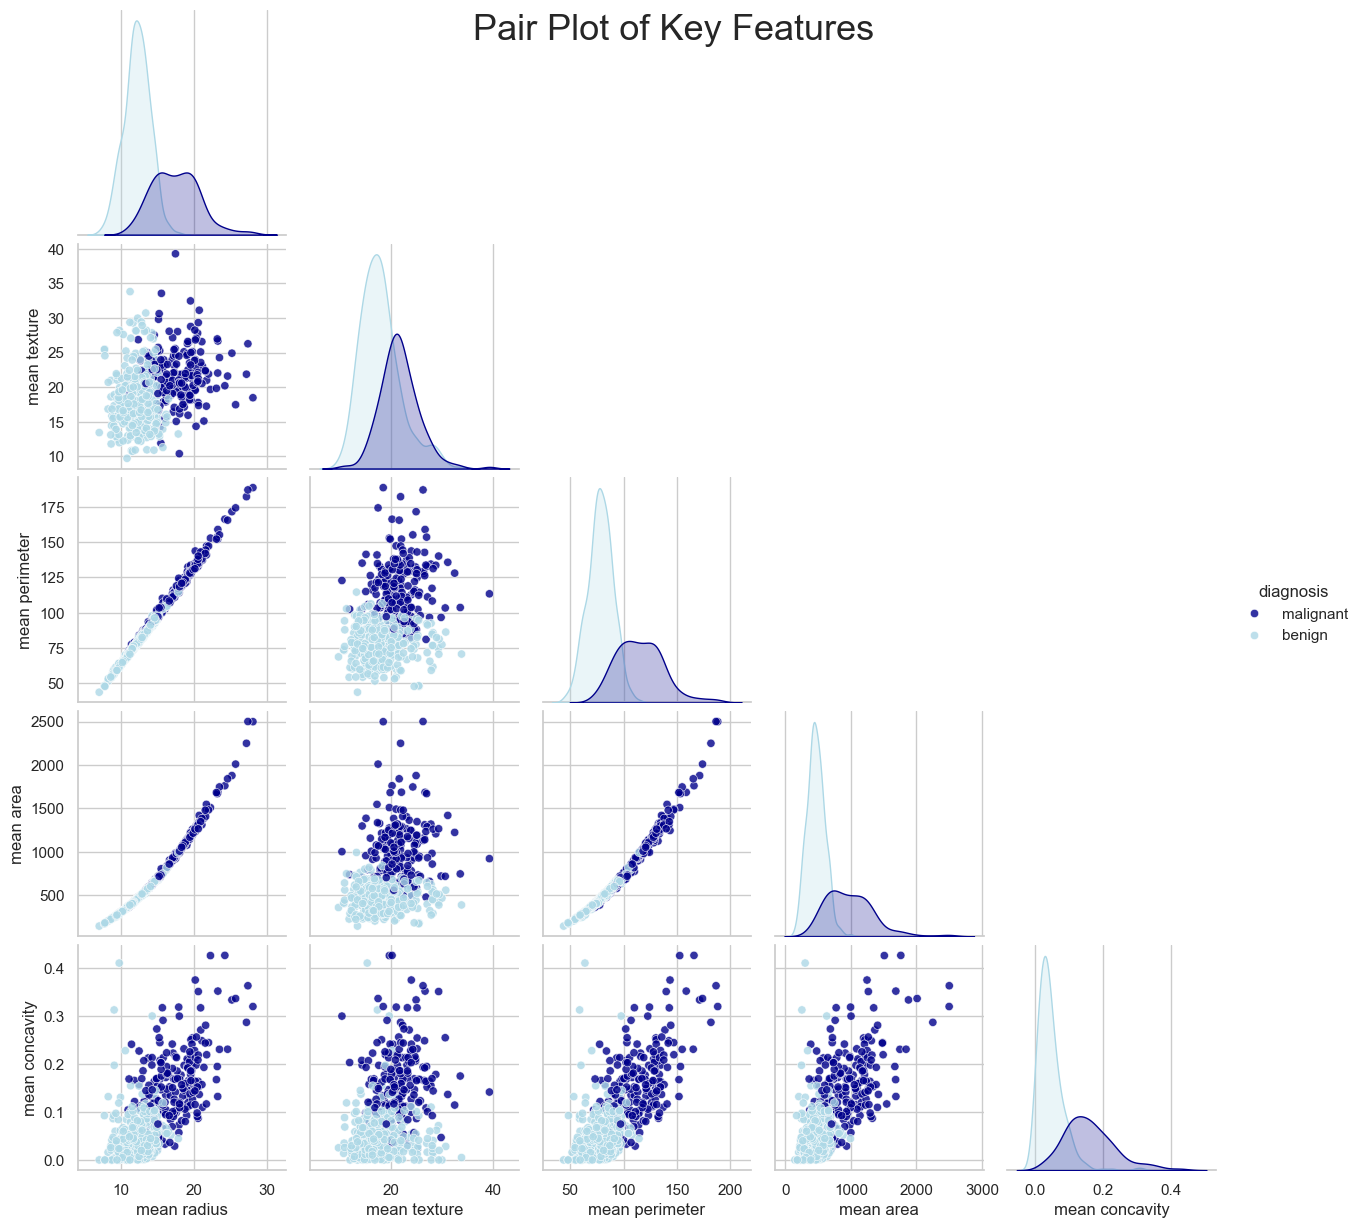

In [ ]:
# select some strongly discriminative features
key_ft = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity"]

sns.pairplot(
    df, 
    vars = key_ft,
    hue = "diagnosis",
    diag_kind = "kde",
    corner = True,
    plot_kws = {"alpha":0.8},
    palette = cols
)

plt.grid(None)
plt.suptitle("Pair Plot of Key Features", fontsize = 26)
plt.show()

# 6. Distribution Scaling Considerations
### Raw (Unstandardized)

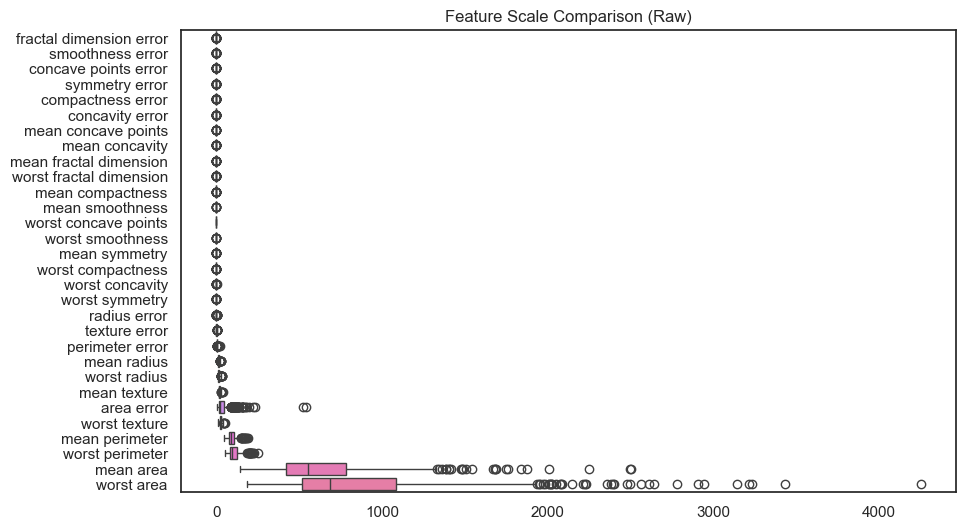

In [126]:
plt.figure(figsize=(10,6))
ordered_feats = df[df.drop(columns="diagnosis").columns].median().sort_values().index
sns.boxplot(data=df[ordered_feats], orient="h")
plt.title("Feature Scale Comparison (Raw)")
plt.show()

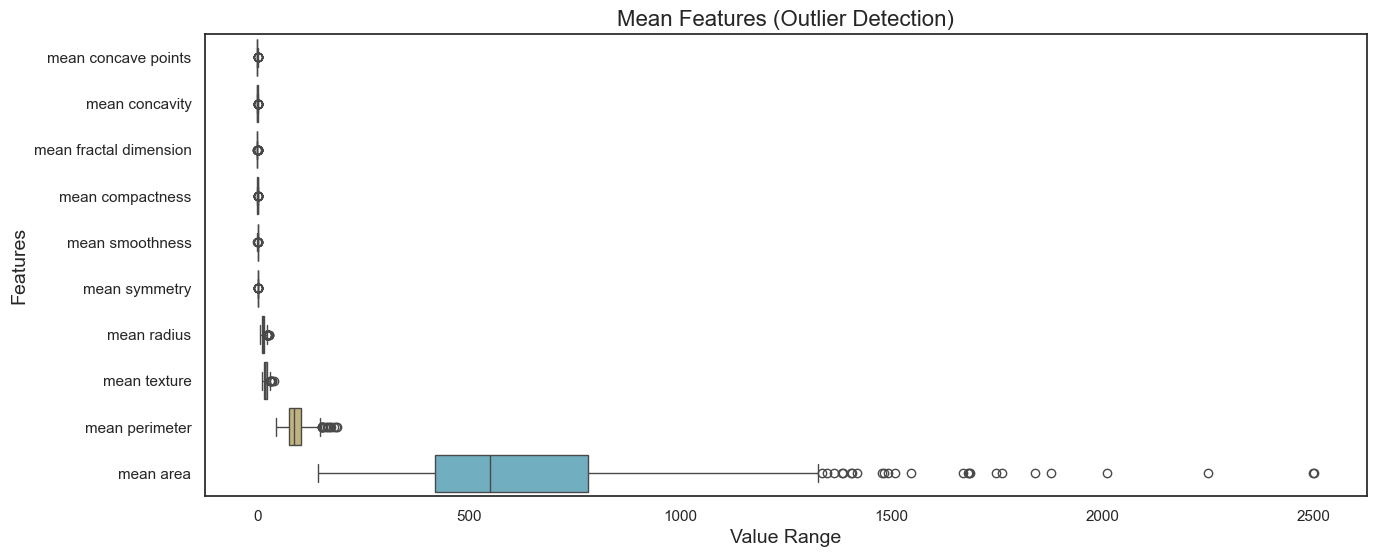

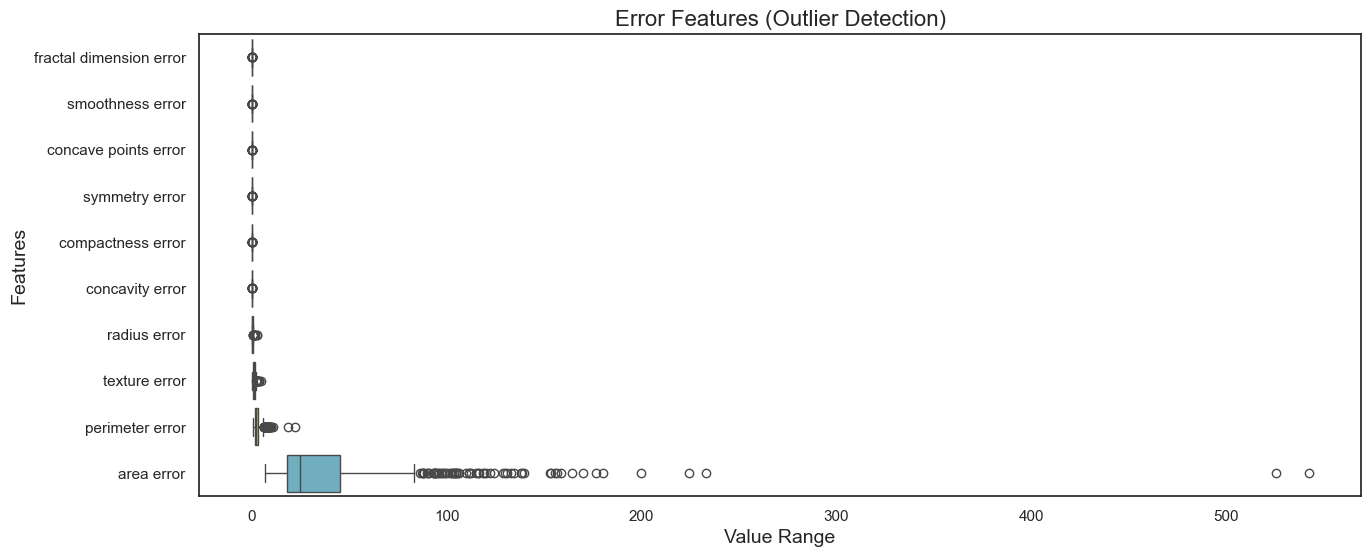

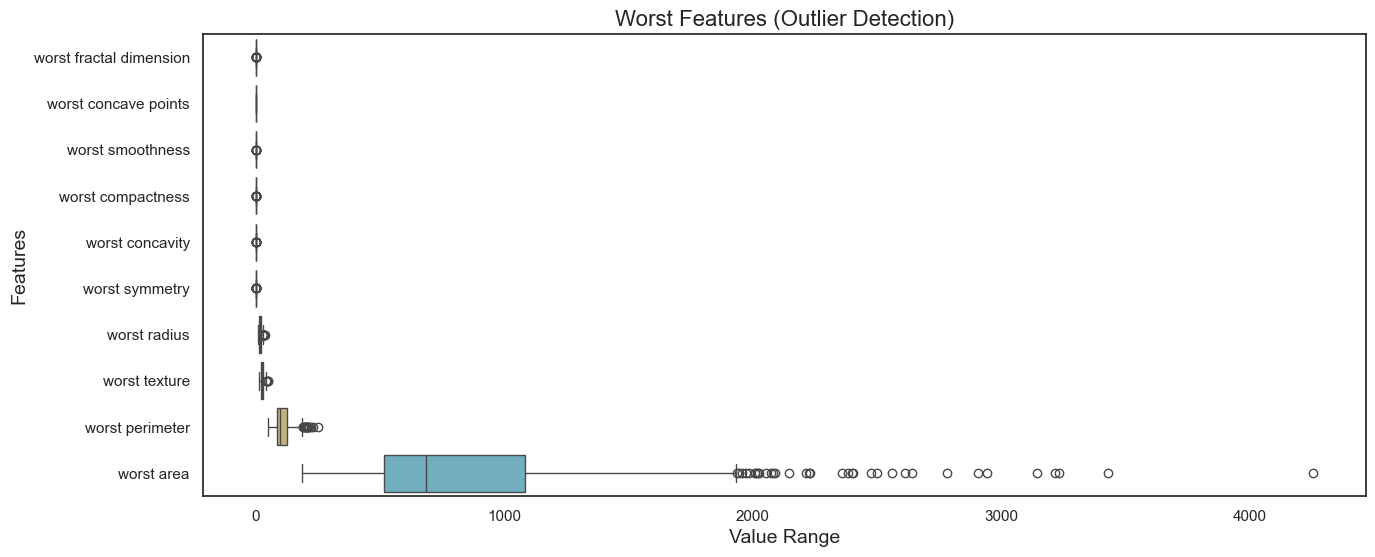

In [116]:
## Boxplot visualization of outliers

# create one boxplot per measure
for m in measures:
    feats = [col for col in df.columns if col.__contains__(m)]

    plt.figure(figsize=(15, 6))
    ordered_feats = df[feats].median().sort_values().index

    sns.boxplot(data=df[ordered_feats], orient="h")
    plt.title(f"{m.title()} Features (Outlier Detection)", fontsize=16)
    plt.xlabel("Value Range", fontsize=14)
    plt.ylabel("Features", fontsize=14)
    plt.show()

### Standardized 

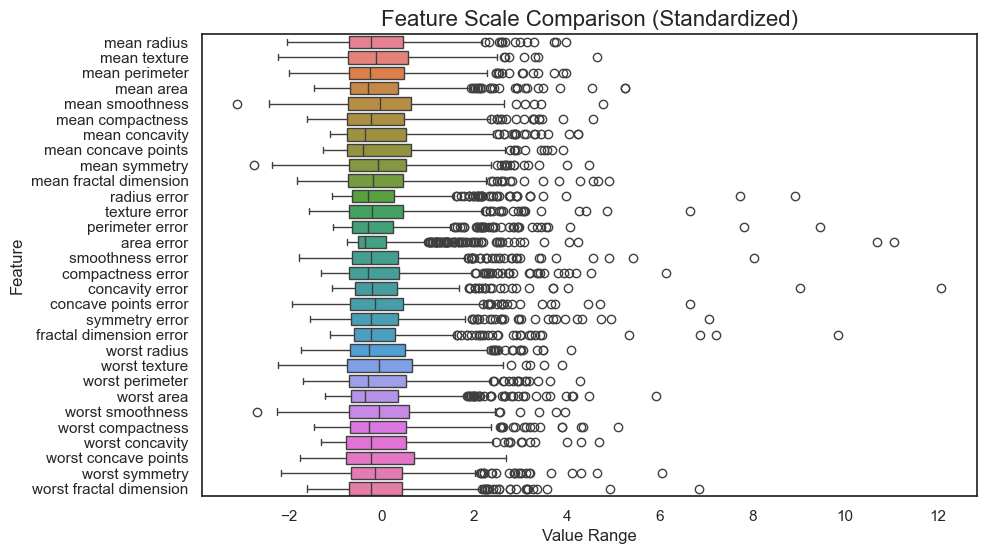

In [134]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df.drop(columns="diagnosis"))
scaled_df = pd.DataFrame(scaled, columns=df.columns[:-1])

plt.figure(figsize=(10,6))
sns.boxplot(data=scaled_df,orient="h")
plt.title("Feature Scale Comparison (Standardized)", fontsize=16)
plt.ylabel("Feature")
plt.xlabel("Value Range")
plt.show()

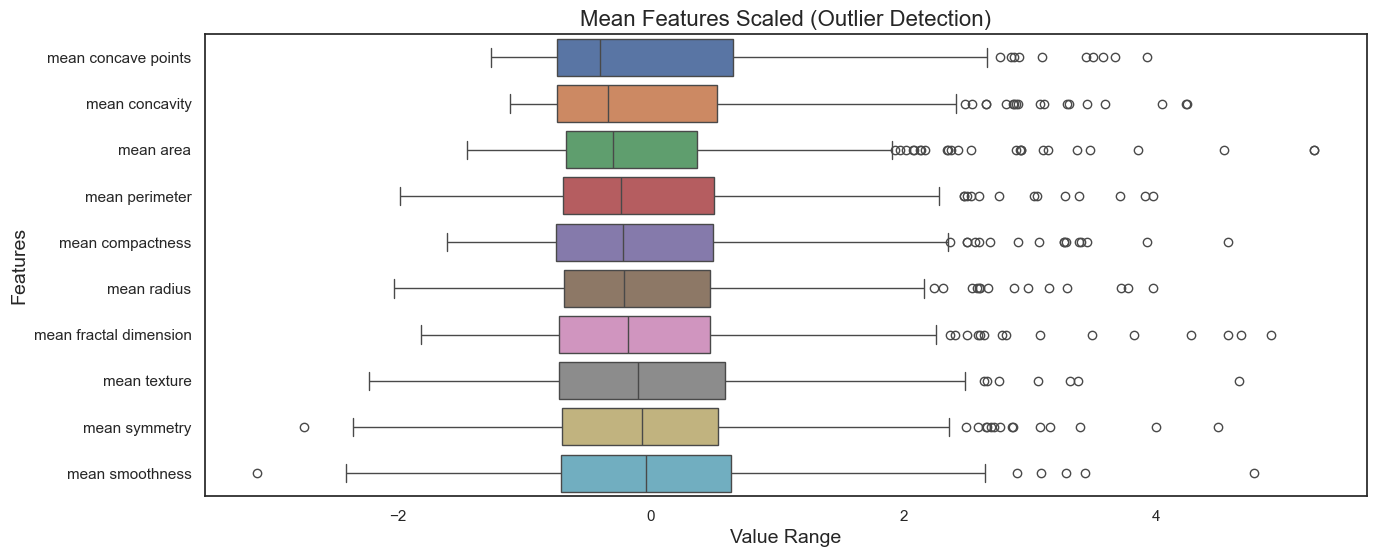

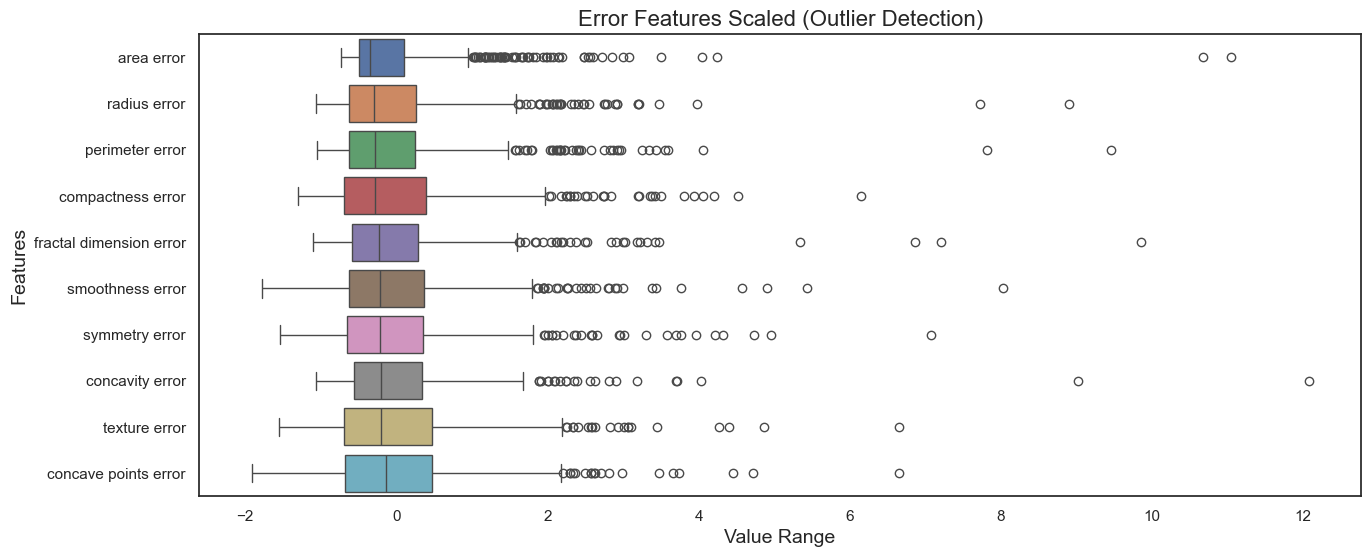

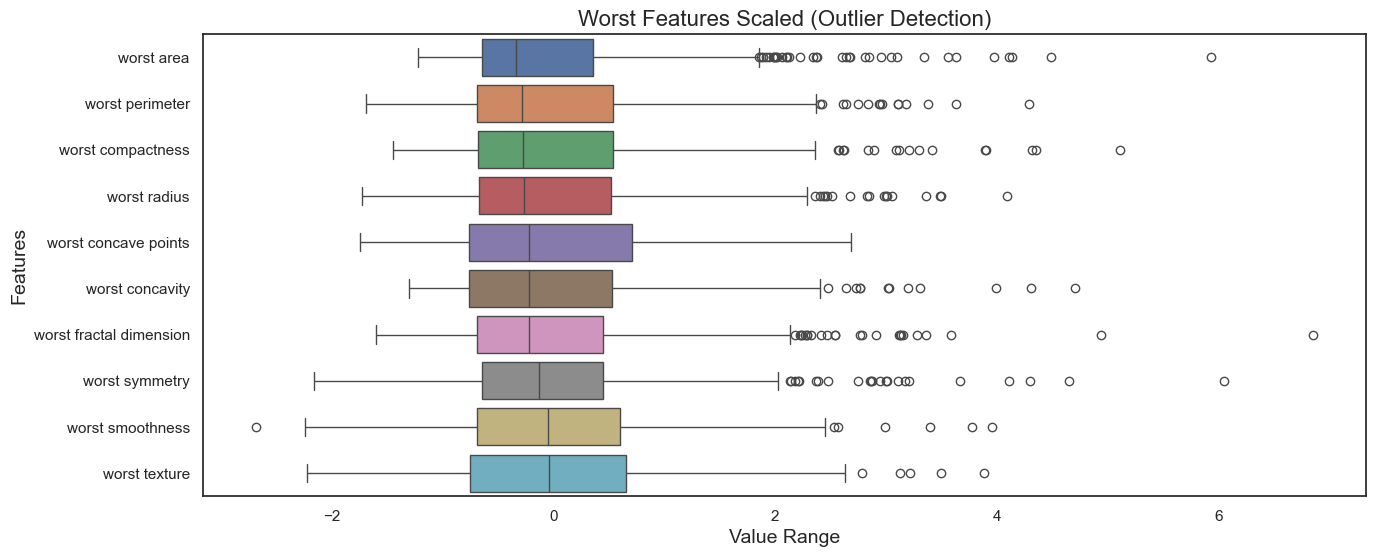

In [133]:
# create one boxplot per measure
for m in measures:
    feats = [col for col in scaled_df.columns if col.__contains__(m)]

    plt.figure(figsize=(15, 6))
    ordered_feats = scaled_df[feats].median().sort_values().index

    sns.boxplot(data=scaled_df[ordered_feats], orient="h")
    plt.title(f"{m.title()} Features Scaled (Outlier Detection)", fontsize=16)
    plt.xlabel("Value Range", fontsize=14)
    plt.ylabel("Features", fontsize=14)
    plt.show()

# 7. Preliminary Feature Importance
As an exploratory step, we ran a random forest classifier and logistic regression to see which features contribute most to model performance. Add sentence about what one can tell us the other cannot, and what we expect to see given what the EDA has shown so far.

## 7.1 Random Forest
Random forest captures complex non-linear patterns in data and can find correlations between features. Feature importance scores tell us which cell morphology measurements are most predictive. This is valuable for clinical interpretation. We will only run a baseline model, no tuning.

<!-- double confirm that standard scaler not needed for RF -->

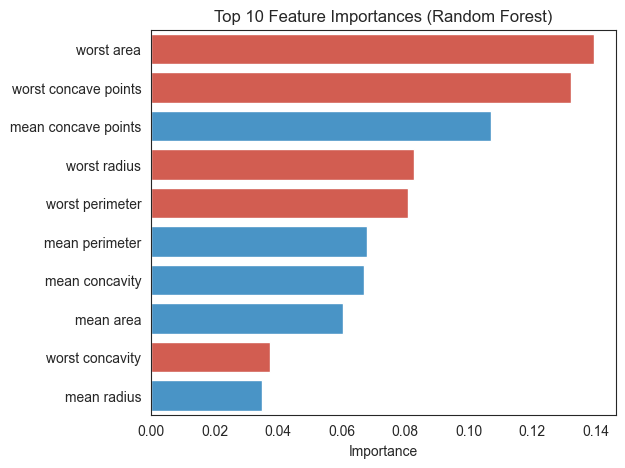

In [43]:
X = df.drop(columns = "diagnosis")
y = df["diagnosis"].map({"malignant": 0, "benign": 1})

rf = RandomForestClassifier(random_state = 42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index = X.columns)
top10 = importances.sort_values(ascending = False).head(10)

pal = [
    measures_cols[next(m for m in measures if m in f)]
    for f in top10.index
]

plt.figure(figsize=(6,5))
sns.barplot(
    x = top10.values, 
    y = top10.index,
    hue = top10.index,
    palette = pal,
    legend = False
)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel(None)
plt.show()

### Observations:

## 7.2 Logistic Regression
Logistic regression captures linear relationships between variables, and coefficient magnitudes represent the amount each feature contributes to the model performance. As previously mentioned, we must take differences in scales into consideration prior to running the logistic regression. Insert why and impacts. We will only run a baseline model, no regularization.

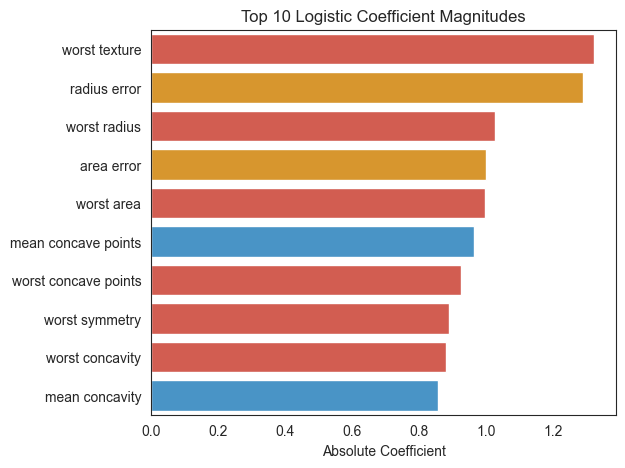

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter = 500)
lr.fit(X_scaled, y)

coefs = pd.Series(abs(lr.coef_[0]), index = X.columns)
top10 = coefs.sort_values(ascending = False).head(10)

pal = [
    measures_cols[next(m for m in measures if m in f)]
    for f in top10.index
]

plt.figure(figsize = (6, 5))
sns.barplot(
    x = top10.values, 
    y = top10.index,
    hue = top10.index,
    palette = pal,
    legend = False    
)
plt.title("Top 10 Logistic Coefficient Magnitudes")
plt.xlabel("Absolute Coefficient")
plt.ylabel(None)
plt.show()

### Observations:

<!-- ## 6.1 Summary of Exploratory Data Analysis
## 6.2 Dataset-Level Risks
## 6.3 Modeling Risks
## 6.4 Ethical & Practical Risks -->

# 7. Proposed Modelling Plan

## 7.1 Potential Risks Revealed by EDA
- Strong multicollinearity suggests regularization is necessary
- Scaling is required for linear models
- Redundant predictors motivate dimensionality reduction or shrinkage
- Small sample size increases risk of coefficient instability
- ROC-AUC is preferred over accuracy due to mild class imbalance
- train/test split with stratification due to mild class imbalance

## 7.2 Models
**Linear Models (Logistic Regression)**:
- no regularization (baseline)
- L1 regularization (Lasso)
- L2 regularization (Ridge)

**Advanced Models**:
- Random forest (baseline)
- Random forest (tuned)
- Support vector machine
<!-- - PCA -->

## 7.3 Model Evaluation
- Accuracy
- Sensitivity
- Specificity
- AUC-ROC
- False Negatives (Misses)
- False Positives (False Alarms)

## 7.4 Model Comparisons 
- logistic unregularized vs L1 vs L2
    - shows effect of multicollinearity, shrinkage, feature selection
- logistic vs RF
    - interpretability vs performance tradeoff
- full-feature logistic vs PC (add-on)
    - redundancy management, structural understanding

## 7.5 Interpretability, Reliability, Robustness, Stability
- multicollinearity (feature heatmap)
- coefficient magnitude
- feature importance
- SHAP values for selected models (add-on)
- decision & calibration curves (add-on)


<!-- 
## EDA

## Logistic

## Advanced

## Evaluation & Selection

## Interpretation (Report) 
-->


~ `
<!-- # 6. Potential Risks Revealed by EDA
## Summary
1. Strong multicollinearity suggests regularization is necessary
2. Scaling is required for linear models
3. Redundant predictors motivate dimensionality reduction or shrinkage
4. Small sample size increases risk of coefficient instability
5. ROC-AUC is preferred over accuracy due to mild class imbalance -->

<!-- ### 1. Severe Multicollinearity
**Evidence**: 
- correlation heatmap shows strong blocks (radius-perimeter-area features)
- correlations often > 0.8
- clear feature grouping (mean/error/worst)
- likely high VIF values

**Modelling Risk**:
- logistic regression coefficients unstable
- inflated standard errors
- sign flips across folds
- less trust in interpretability
- possible overfitting

**Where Addressed**:
- baseline logistic (to demonstrate instability)
- L2 regularization (coefficient shrinkage)
- L1 regularization (feature selection)
- VIF quantification
- Stability analysis (if included)
- PCA (if included)


### 2. Feature Scale Differences
**Evidence**: 
- wide variation in magnitudes across features
- some features span large ranges

**Modelling Risk**:
- logistic regression unstable without scaling
- regularization behaves inconsistently
- SVM sensitive to scaling

**Where Addressed**:
- `StandardScaler` before all linear models
- explicit justification for scaling


### 3. Redundant Predictors
**Evidence**: 
- families of measurements (mean/error/worst)
- highly correlated geometric features

**Modelling Risk**:
- unnecessary complexity
- diminished interpretability
- redundancy provides no performance gain

**Where Addressed**:
- L1 regularization
- PCA comparison (if done)
- random forest feature importance


### 4. Small Dataset Size (Relative to Feature Count)
**Evidence**: ~569 samples, but 30 predictors
**Modelling Risk**:
- overfitting potential
- high variance estimates
- sensitivity to data splits

**Where Addressed**: 
- cross-validation
- stability analysis (if included)
- regularization
- learning curves (optional)


### 5. Class Imbalance (Mild-Moderate)
**Evidence**: benign > malignant
**Modelling Risk**: 
- accuracy metric is misleading
- threshold sensitivity

**Where Addressed**:
- ROC-AUC as primary metric
- sensitivity/specificity discussion
- calibration layer (if included) -->

--- 

Author: SE Creighton